# Boatos.org: spider-level EDA

Fixed sections:
1. Run selection and player evidence
2. Volume, temporal coverage, and quality overview
3. Text-length histograms by original_label and standard_label
4. Category, topic/tag, and temporal distribution
5. Missing fields and invalid dates
6. Cleaning and normalization review
7. NLP with stop-word removal, lemmas, and NER
8. Processed JSONL export


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Repositorio nao encontrado a partir do diretorio atual.")


REPO_ROOT = _find_repo_root()
for path in (REPO_ROOT, REPO_ROOT / "src", REPO_ROOT / "notebooks"):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import eda_utils as eu

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", palette="crest")

## Run selection and player evidence

In [2]:
SPIDER = "boatos_org"
PLAYER = "Boatos.org"
DATA_DIR = eu.resolve_data_dir(str(REPO_ROOT / "data"))
SNAPSHOT_ID = None
BATCH_SIZE = 64

selection = eu.select_spider_run(DATA_DIR, SPIDER)
profile = eu.get_spider_profile(SPIDER)
display(eu.selection_to_frame(selection))
profile

,spider,agency_id,agency_name,selected_run_id,latest_run_id,latest_valid_run_id,fallback_applied,selection_reason,cleaning_flags,diagnostic_run_ids
0,boatos_org,boatos_org,Boatos.org,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix",


SpiderProfile(spider='boatos_org', display_name='Boatos.org', analysis_field_order=('title', 'claim', 'summary'), ignored_analysis_titles=frozenset(), dropped_export_titles=frozenset(), extract_label_prefix_before_colon=False, diagnostic_run_ids=(), cleaning_flags=('html_unescape', 'unicode_normalize', 'collapse_whitespace', 'light_encoding_fix'))

In [3]:
runs_df = eu.load_runs_df(DATA_DIR)
spider_runs = runs_df.loc[runs_df["spider"] == SPIDER].sort_values(
    "run_started_at", ascending=False
)
evidence_cols = [
    "run_id",
    "run_started_at",
    "run_finished_at",
    "items_seen",
    "items_stored",
    "items_deduped",
    "items_invalid",
    "has_items_file",
    "is_valid",
]
display(spider_runs[evidence_cols].head(10))

diagnostic_df = eu.diagnostic_runs_df(DATA_DIR, SPIDER)
if not diagnostic_df.empty:
    print("Diagnostic runs configured for this spider:")
    display(diagnostic_df[evidence_cols])

,run_id,run_started_at,run_finished_at,items_seen,items_stored,items_deduped,items_invalid,has_items_file,is_valid
15,20260315T010005Z-1d265f16,2026-03-15 01:00:05+00:00,2026-03-15 07:03:08+00:00,12869,12869,0,0,True,True


## Volume, temporal coverage, and quality overview

In [4]:
nlp = eu.load_nlp_model()
raw_df = eu.load_spider_items_df(DATA_DIR, SPIDER, selection.selected_run_id)
selection, processed_records = eu.build_processed_records(
    DATA_DIR,
    SPIDER,
    selection=selection,
    nlp=nlp,
    batch_size=BATCH_SIZE,
)
processed_df = eu.processed_records_to_df(processed_records)
processed_df["published_at_dt"] = pd.to_datetime(
    processed_df["published_at"], utc=True, errors="coerce"
)

overview = pd.DataFrame(
    [
        {
            "player": PLAYER,
            "selected_run_id": selection.selected_run_id,
            "latest_run_id": selection.latest_run_id,
            "fallback_applied": selection.fallback_applied,
            "raw_rows": len(raw_df),
            "processed_rows": len(processed_df),
            "dropped_rows": len(raw_df) - len(processed_df),
            "coverage_start": processed_df["published_at_dt"].min(),
            "coverage_end": processed_df["published_at_dt"].max(),
            "invalid_dates": int(processed_df["published_at_dt"].isna().sum()),
            "missing_original_label": int(processed_df["original_label"].isna().sum()),
        }
    ]
)
display(overview)
display(raw_df.head(3))
display(processed_df.head(3))

,player,selected_run_id,latest_run_id,fallback_applied,raw_rows,processed_rows,dropped_rows,coverage_start,coverage_end,invalid_dates,missing_original_label
0,Boatos.org,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,12869,12869,0,2013-06-26 18:54:03+00:00,2026-03-14 17:34:50+00:00,0,1963


,item_id,agency_id,agency_name,spider,source_url,canonical_url,title,published_at,collected_at,claim,summary,verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical
0,a599c53b83b849cb01ec901210d80dddc8834b9be8ea128363aa3232a00cb8a5,boatos_org,Boatos.org,boatos_org,https://www.boatos.org/entretenimento/informacao-de-que-justin-bieber-vai-encerrar-carreira-em-2014-e-falsa.html,https://www.boatos.org/entretenimento/informacao-de-que-justin-bieber-vai-encerrar-carreira-em-2014-e-falsa.html,Informação de que Justin Bieber vai encerrar carreira em 2014 é falsa,2014-01-03T02:01:14+00:00,2026-03-15T01:16:42+00:00,Informação de que Justin Bieber vai encerrar carreira em 2014 é falsa,Boato – O cantor pop Justin Bieber vai encerrar a carreira no ano de 2014. Ele pretende investir em outras atividades que não seja a música.,Falso,Falso,pt-BR,BR,[Entretenimento],[],[],NewsArticle,20260315T010005Z-1d265f16,2014-01-03 02:01:14+00:00,2026-03-15 01:16:42+00:00,106895.257778,69,69,140,www.boatos.org,1.0
1,86ba08ba30a48d14e8adbaef0e18743bfd54875f7608196ad66a19d3a65bc660,boatos_org,Boatos.org,boatos_org,https://www.boatos.org/politica/alckmin-professores-rabalhar-por-amor.html,https://www.boatos.org/politica/alckmin-professores-rabalhar-por-amor.html,"Alckmin diz que professores têm que trabalhar por amor, não por dinheiro #boato",2016-09-14T01:49:02+00:00,2026-03-15T01:16:43+00:00,"Alckmin diz que professores têm que trabalhar por amor, não por dinheiro","Boato – Governador de São Paulo declarou que os professores da rede pública devem trabalhar só por amor ao ensino, não por dinheiro.",Falso,Falso,pt-BR,BR,[Política],[],[],NewsArticle,20260315T010005Z-1d265f16,2016-09-14 01:49:02+00:00,2026-03-15 01:16:43+00:00,83255.461389,79,72,132,www.boatos.org,1.0
2,51f889f82ecd1f845668be398e27c1c3c3e5db014474339ad3e20d8b412f2227,boatos_org,Boatos.org,boatos_org,https://www.boatos.org/politica/dilma-sacrificio-cao-nego.html,https://www.boatos.org/politica/dilma-sacrificio-cao-nego.html,"Afinal, o que aconteceu na história de Dilma e o sacrifício do cão Nego?",2016-09-13T02:18:46+00:00,2026-03-15T01:16:43+00:00,"Afinal, o que aconteceu na história de Dilma e o sacrifício do cão Nego?","A história do cão de Dilma tomou conta na internet. No meio de tantas versões e contradições, escrevemos este texto para esclarecer o caso",NaN,NaN,pt-BR,BR,[Política],[],[],NewsArticle,20260315T010005Z-1d265f16,2016-09-13 02:18:46+00:00,2026-03-15 01:16:43+00:00,83278.965833,72,72,138,www.boatos.org,1.0


,record_id,source_record_id,dataset_id,source_url,published_at,language,title,author,subtitle,claim_text,body_text,analysis_text,text_for_ner,text_without_stopwords,lemmatized_text,original_label,standard_label,category,entities,variant,metadata.analysis_text_length,metadata.entity_count,metadata.spider,metadata.agency_id,metadata.agency_name,metadata.run_id,metadata.latest_run_id,metadata.fallback_applied,metadata.source_type,metadata.source_topics,metadata.source_tags,metadata.source_rating,published_at_dt
0,factcheck_scrape_boatos_org:a599c53b83b849cb01ec901210d80dddc8834b9be8ea128363aa3232a00cb8a5,a599c53b83b849cb01ec901210d80dddc8834b9be8ea128363aa3232a00cb8a5,factcheck_scrape_boatos_org,https://www.boatos.org/entretenimento/informacao-de-que-justin-bieber-vai-encerrar-carreira-em-2014-e-falsa.html,2014-01-03T02:01:14+00:00,pt-BR,Informação de que Justin Bieber vai encerrar carreira em 2014 é falsa,None,None,Informação de que Justin Bieber vai encerrar carreira em 2014 é falsa,Boato – O cantor pop Justin Bieber vai encerrar a carreira no ano de 2014. Ele pretende investir em outras atividades que não seja a música.,informação de que justin bieber vai encerrar carreira em 2014 é falsa boato – o cantor pop justin bieber vai encerrar a carreira no ano de 2014. ele pretend...,informação de que justin bieber vai encerrar carreira em 2014 é falsa boato – o cantor pop justin bieber vai encerrar a carreira no ano de 2014. ele pretend...,informação justin bieber encerrar carreira 2014 falsa boato cantor pop justin bieber encerrar carreira ano 2014 pretende investir atividades seja música,informação de que justin bieber ir encerrar carreira em 2014 ser falso boato o cantor pop justin bieber ir encerrar o carreira em o ano de 2014 ele pretende...,Falso,false,Entretenimento,"[{'text': 'justin bieber', 'label': 'PER', 'start_char': 18, 'end_char': 31}, {'text': 'justin bieber', 'label': 'PER', 'start_char': 91, 'end_char': 104}]",claim_summary,210,2,boatos_org,boatos_org,Boatos.org,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,NewsArticle,[Entretenimento],[],Falso,2014-01-03 02:01:14+00:00
1,factcheck_scrape_boatos_org:86ba08ba30a48d14e8adbaef0e18743bfd54875f7608196ad66a19d3a65bc660,86ba08ba30a48d14e8adbaef0e18743bfd54875f7608196ad66a19d3a65bc660,factcheck_scrape_boatos_org,https://www.boatos.org/politica/alckmin-professores-rabalhar-por-amor.html,2016-09-14T01:49:02+00:00,pt-BR,"Alckmin diz que professores têm que trabalhar por amor, não por dinheiro #boato",None,None,"Alckmin diz que professores têm que trabalhar por amor, não por dinheiro","Boato – Governador de São Paulo declarou que os professores da rede pública devem trabalhar só por amor ao ensino, não por dinheiro.","alckmin diz que professores têm que trabalhar por amor, não por dinheiro #boato alckmin diz que professores têm que trabalhar por amor, não por dinheiro boa...","alckmin diz que professores têm que trabalhar por amor, não por dinheiro #boato alckmin diz que professores têm que trabalhar por amor, não por dinheiro boa...",alckmin professores trabalhar amor dinheiro boato alckmin professores trabalhar amor dinheiro boato governador paulo declarou professores rede pública traba...,alckmin dizer que professor ter que trabalhar por amor não por dinheiro boato alckmin dizer que professor ter que trabalhar por amor não por dinheiro boato ...,Falso,false,Política,"[{'text': 'alckmin', 'label': 'PER', 'start_char': 0, 'end_char': 7}, {'text': 'boato alckmin', 'label': 'PER', 'start_char': 74, 'end_char': 87}, {'text': ...",claim_summary,285,3,boatos_org,boatos_org,Boatos.org,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,NewsArticle,[Política],[],Falso,2016-09-14 01:49:02+00:00
2,factcheck_scrape_boatos_org:51f889f82ecd1f845668be398e27c1c3c3e5db014474339ad3e20d8b412f2227,51f889f82ecd1f845668be398e27c1c3c3e5db014474339ad3e20d8b412f2227,factcheck_scrape_boatos_org,https://www.boatos.org/politica/dilma-sacrificio-cao-nego.html,2016-09-13T02:18:46+00:00

## Text-length histograms by label

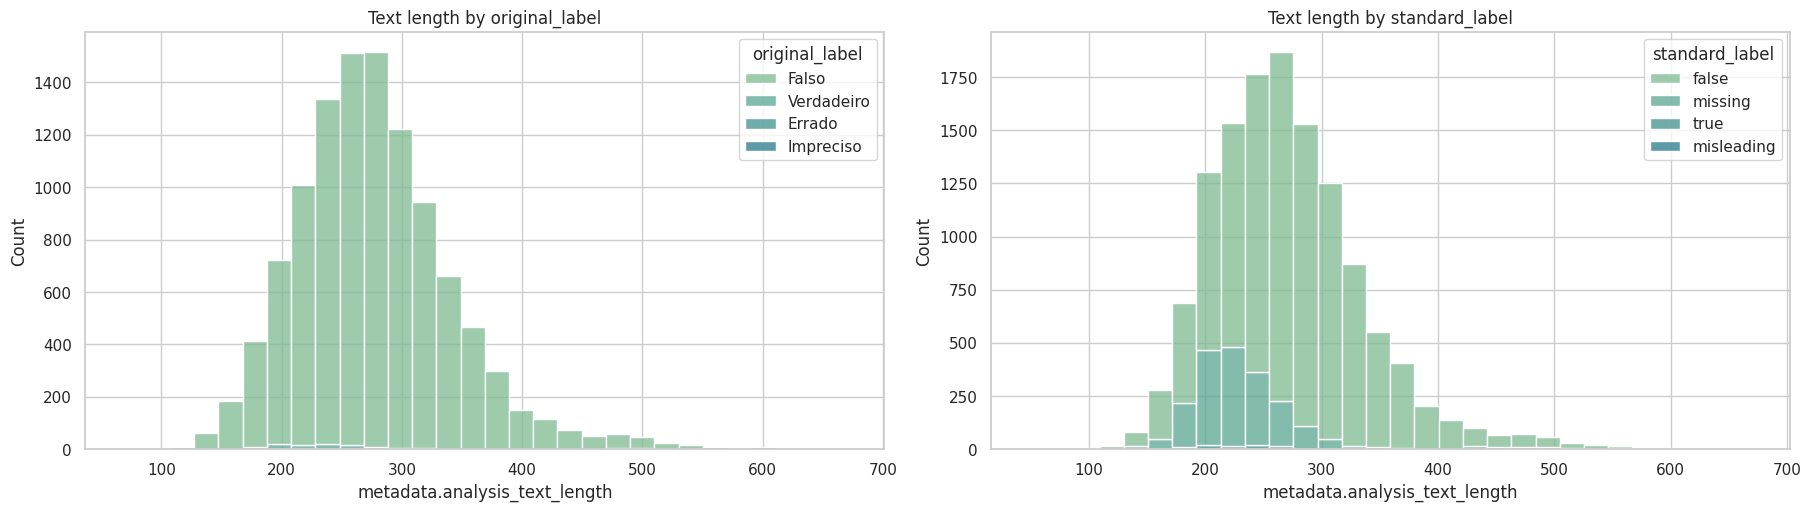

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="original_label",
    bins=30,
    multiple="stack",
    ax=axes[0],
)
axes[0].set_title("Text length by original_label")

sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="standard_label",
    bins=30,
    multiple="stack",
    ax=axes[1],
)
axes[1].set_title("Text length by standard_label")
plt.show()

## Category, topic/tag, temporal distribution, and data quality

In [6]:
topic_counts = raw_df["topics"].explode().dropna().value_counts().head(20)
tag_counts = raw_df["tags"].explode().dropna().value_counts().head(20)
category_counts = processed_df["category"].value_counts(dropna=False).head(20)

display(category_counts.rename_axis("category").reset_index(name="count"))
display(topic_counts.rename_axis("topic").reset_index(name="count"))
display(tag_counts.rename_axis("tag").reset_index(name="count"))

monthly = (
    processed_df.dropna(subset=["published_at_dt"])
    .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .size()
    .reset_index(name="count")
)
display(monthly.tail(24))

missing_fields = (
    raw_df[["title", "claim", "summary", "verdict", "rating", "published_at"]]
    .isna()
    .sum()
    .rename_axis("field")
    .reset_index(name="missing_count")
)
display(missing_fields)

display(
    processed_df.loc[
        processed_df["published_at_dt"].isna(), ["source_record_id", "title", "published_at"]
    ].head(20)
)

,category,count
0,Política,3571
1,Brasil,2045
2,Saúde,1274
3,Tecnologia,1242
4,Mundo,1155
5,Entretenimento,1113
6,Esporte,614
7,Religião,601
8,English,327
9,Español,317


,topic,count
0,Política,3596
1,Brasil,2045
2,Saúde,1283
3,Tecnologia,1249
4,Mundo,1162
5,Entretenimento,1113
6,Esporte,614
7,Religião,607
8,English,327
9,Español,317


,tag,count


/tmp/ipykernel_2046092/1119197242.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())


,month,count
130,2024-04-01,98
131,2024-05-01,149
132,2024-06-01,88
133,2024-07-01,110
134,2024-08-01,78
135,2024-09-01,86
136,2024-10-01,99
137,2024-11-01,97
138,2024-12-01,83
139,2025-01-01,140


,field,missing_count
0,title,0
1,claim,0
2,summary,0
3,verdict,1963
4,rating,1963
5,published_at,0


,source_record_id,title,published_at


## Cleaning and normalization review

In [7]:
comparison = raw_df.rename(
    columns={
        "item_id": "source_record_id",
        "title": "raw_title",
        "claim": "raw_claim",
        "summary": "raw_summary",
        "published_at": "raw_published_at",
        "verdict": "raw_verdict",
    }
).merge(
    processed_df[
        [
            "source_record_id",
            "title",
            "claim_text",
            "body_text",
            "analysis_text",
            "original_label",
            "standard_label",
            "published_at",
        ]
    ],
    on="source_record_id",
    how="left",
)
display(comparison.head(15))

,source_record_id,agency_id,agency_name,spider,source_url,canonical_url,raw_title,raw_published_at,collected_at,raw_claim,raw_summary,raw_verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical,title,claim_text,body_text,analysis_text,original_label,standard_label,published_at
0,a599c53b83b849cb01ec901210d80dddc8834b9be8ea128363aa3232a00cb8a5,boatos_org,Boatos.org,boatos_org,https://www.boatos.org/entretenimento/informacao-de-que-justin-bieber-vai-encerrar-carreira-em-2014-e-falsa.html,https://www.boatos.org/entretenimento/informacao-de-que-justin-bieber-vai-encerrar-carreira-em-2014-e-falsa.html,Informação de que Justin Bieber vai encerrar carreira em 2014 é falsa,2014-01-03T02:01:14+00:00,2026-03-15T01:16:42+00:00,Informação de que Justin Bieber vai encerrar carreira em 2014 é falsa,Boato – O cantor pop Justin Bieber vai encerrar a carreira no ano de 2014. Ele pretende investir em outras atividades que não seja a música.,Falso,Falso,pt-BR,BR,[Entretenimento],[],[],NewsArticle,20260315T010005Z-1d265f16,2014-01-03 02:01:14+00:00,2026-03-15 01:16:42+00:00,106895.257778,69,69,140,www.boatos.org,1.0,Informação de que Justin Bieber vai encerrar carreira em 2014 é falsa,Informação de que Justin Bieber vai encerrar carreira em 2014 é falsa,Boato – O cantor pop Justin Bieber vai encerrar a carreira no ano de 2014. Ele pretende investir em outras atividades que não seja a música.,informação de que justin bieber vai encerrar carreira em 2014 é falsa boato – o cantor pop justin bieber vai encerrar a carreira no ano de 2014. ele pretend...,Falso,false,2014-01-03T02:01:14+00:00
1,86ba08ba30a48d14e8adbaef0e18743bfd54875f7608196ad66a19d3a65bc660,boatos_org,Boatos.org,boatos_org,https://www.boatos.org/politica/alckmin-professores-rabalhar-por-amor.html,https://www.boatos.org/politica/alckmin-professores-rabalhar-por-amor.html,"Alckmin diz que professores têm que trabalhar por amor, não por dinheiro #boato",2016-09-14T01:49:02+00:00,2026-03-15T01:16:43+00:00,"Alckmin diz que professores têm que trabalhar por amor, não por dinheiro","Boato – Governador de São Paulo declarou que os professores da rede pública devem trabalhar só por amor ao ensino, não por dinheiro.",Falso,Falso,pt-BR,BR,[Política],[],[],NewsArticle,20260315T010005Z-1d265f16,2016-09-14 01:49:02+00:00,2026-03-15 01:16:43+00:00,83255.461389,79,72,132,www.boatos.org,1.0,"Alckmin diz que professores têm que trabalhar por amor, não por dinheiro #boato","Alckmin diz que professores têm que trabalhar por amor, não por dinheiro","Boato – Governador de São Paulo declarou que os professores da rede pública devem trabalhar só por amor ao ensino, não por dinheiro.","alckmin diz que professores têm que trabalhar por amor, não por dinheiro #boato alckmin diz que professores têm que trabalhar por amor, não por dinheiro boa...",Falso,false,2016-09-14T01:49:02+00:00
2,51f889f82ecd1f845668be398e27c1c3c3e5db014474339ad3e20d8b412f2227,boatos_org,Boatos.org,boatos_org,https://www.boatos.org/politica/dilma-sacrificio-cao-nego.html,https://www.boatos.org/politica/dilma-sacrificio-cao-nego.html,"Afinal, o que aconteceu na história de Dilma e o sacrifício do cão Nego?",2016-09-13T02:18:46+00:00,2026-03-15T01:16:43+00:00,"Afinal, o que aconteceu na história de Dilma e o sacrifício do cão Nego?","A história do cão de Dilma tomou conta na internet. No meio de tantas versões e contradições, escrevemos este texto para esclarecer o caso",NaN,NaN,pt-BR,BR,[Política],[],[],NewsArticle,20260315T010005Z-1d265f16,2016-09-13 02:18:46+00:00,2026-03-15 01:16:43+00:00,83278.965833,72,72,138,www.boatos.org,1.0,"Afinal, o que aconteceu na história de Dilma e o sacrifício do cão Nego?","Afinal, o que aconteceu na história de Dilma e o sacrifício do cão Nego?","A história do cão de Dilma tomou conta na internet. No meio de tantas versões e contradições, escrevemos este texto para esclarecer o ca

## NLP outputs

In [8]:
lemma_counts = (
    processed_df["lemmatized_text"].str.split().explode().dropna().value_counts().head(20)
)
display(lemma_counts.rename_axis("lemma").reset_index(name="count"))

entity_series = processed_df["entities"].explode().dropna()
if entity_series.empty:
    entity_df = pd.DataFrame(columns=["text", "label", "start_char", "end_char"])
else:
    entity_df = pd.json_normalize(entity_series)

display(entity_df.head(20))
display(entity_df["label"].value_counts().rename_axis("label").reset_index(name="count"))
display(processed_df[["source_record_id", "text_without_stopwords", "lemmatized_text"]].head(10))

,lemma,count
0,o,60520
1,de,48290
2,em,25621
3,que,19766
4,boato,16532
5,ser,14033
6,e,13917
7,um,8363
8,para,7364
9,a,6628


,text,label,start_char,end_char
0,justin bieber,PER,18,31
0,justin bieber,PER,91,104
1,alckmin,PER,0,7
1,boato alckmin,PER,74,87
1,de são paulo,LOC,172,184
2,dilma,PER,39,44
2,dilma,PER,94,99
2,internet,MISC,115,123
3,joesley batista,PER,0,15
3,joesley batista,PER,71,86


,label,count
0,PER,19857
1,LOC,18981
2,ORG,5602
3,MISC,4283


,source_record_id,text_without_stopwords,lemmatized_text
0,a599c53b83b849cb01ec901210d80dddc8834b9be8ea128363aa3232a00cb8a5,informação justin bieber encerrar carreira 2014 falsa boato cantor pop justin bieber encerrar carreira ano 2014 pretende investir atividades seja música,informação de que justin bieber ir encerrar carreira em 2014 ser falso boato o cantor pop justin bieber ir encerrar o carreira em o ano de 2014 ele pretende...
1,86ba08ba30a48d14e8adbaef0e18743bfd54875f7608196ad66a19d3a65bc660,alckmin professores trabalhar amor dinheiro boato alckmin professores trabalhar amor dinheiro boato governador paulo declarou professores rede pública traba...,alckmin dizer que professor ter que trabalhar por amor não por dinheiro boato alckmin dizer que professor ter que trabalhar por amor não por dinheiro boato ...
2,51f889f82ecd1f845668be398e27c1c3c3e5db014474339ad3e20d8b412f2227,afinal aconteceu história dilma sacrifício cão nego história cão dilma tomou conta internet tantas versões contradições escrevemos texto esclarecer caso,afinal o que acontecer em o história de dilma e o sacrifício de o cão negar o história de o cão de dilma tomar contar em o internet em o meio de tanto versã...
3,1d830021860bc4a69dd2c13612f86332e29a35a59595f0c7d08347f87c66b6c4,joesley batista envenenado laudo polícia científica boato joesley batista envenenado laudo polícia científica boato polícia científica confirmou joesley bat...,joesley batista ser envenenar dizer laudo de o polícia científico boato joesley batista ser envenenar dizer laudo de o polícia científico boato polícia cien...
4,950fecdf091ae9b2cc7a2252bbe9976bc34f1b707cd11287776cc386c956bd7a,pegadinha jovem ganha mega-sena virada posta foto facebook boato sorteado mega-sena virada homem postou foto bilhete premiado facebook ação recebeu críticas...,pegadinha jovem ganhar em o mega-sena de o virada e pôr foto em o facebook boato após ser sortear em o mega-sena de o virada um homem postar o foto de o bil...
5,2ec51f8ba6ba5a042a20572df1d3e19c00a199056cbb78495414bca259e06e05,gritaram prendam lula paixão cristo jerusalém boato gritaram prendam lula paixão cristo jerusalém boato encenação paixão cristo jerusalém alguém gritou pren...,gritar prendar o lula em o paixão de cristo de novo jerusalém boato gritar prendar o lula em o paixão de cristo de novo jerusalém boato em o encenação de o ...
6,2fa789ed6fe6a46ebac0f15eeb5f790d985a3f3b5540cc6a986460e91286c862,homem engravida sogra filha enteada rio sul boato homem engravida sogra filha enteada rio sul boato g1 noticiou homem engravidou sogra filha enteada caso oc...,homem engravidar sogra filha e entear em o rio grande de o sul boato homem engravidar sogra filha e entear em o rio grande de o sul boato g1 noticiar que um...
7,2c92fbb8af0614020aca96a93002fb14ecc6e10392520abea35e01c8956accb8,falso criminoso conteúdo aponta vacinados covid-19 passar exame cardíaco prevenir morte súbita checamos mensagens apontam indivíduos vacinados covid-19 pass...,ser falso e criminoso conteúdo que apontar que todo o vacinado contra covid-19 dever passar por exame cardíaco para prevenir morte súbito checamos mensagem ...
8,37f50a473a2c09a519a4160f689a30304876bcd52c5e959e503bf55442278b62,it is false and criminal content that claims all those vaccinated against covid-19 must undergo heart exam to prevent sudden death we fact-checked claims su...,it is false and criminal content that claims all those vaccinated against covid-19 must undergo a heart exam to prevent sudden death we fact-checked claims ...
9,07c64d7f1cbbbea45138008cdfb000b78f74dda882b5975593cb9413781dfc00,fake news literie descobre dívida r$ 20 bilhões liquida roupas boato literie descobriu dívida r$ 20 bilhões liquidando roupas egípcias site incrível,fake news literie descobrir dívida de r$ 20 bilhão e liquir roupa boato a literie descobrir um dívida de r$ 20 bilhão e por isso estar liquidar roupa egípci...


## Export processed JSONL

In [9]:
export_info = eu.export_processed_records(
    DATA_DIR,
    SPIDER,
    records=processed_records,
    selection=selection,
    snapshot_id=SNAPSHOT_ID,
)

display(
    pd.DataFrame(
        [
            {
                "snapshot_id": export_info["snapshot_id"],
                "record_count": export_info["record_count"],
                "spider_path": str(export_info["spider_path"]),
                "combined_path": str(export_info["combined_path"]),
                "manifest_path": str(export_info["manifest_path"]),
            }
        ]
    )
)

,snapshot_id,record_count,spider_path,combined_path,manifest_path
0,20260315T231924Z-boatos_org,12869,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T231924Z-boatos_org/spiders/boatos_org.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T231924Z-boatos_org/factcheck_scrape_unified.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T231924Z-boatos_org/manifest.json
